# Part 1g: Hyperparameter Tuning with Keras Tuner

This notebook demonstrates how to use Keras Tuner for automated hyperparameter optimization.

## Topics Covered:
1. Keras Tuner Setup
2. RandomSearch Tuner
3. Hyperband Tuner
4. BayesianOptimization Tuner
5. Custom Hyperparameter Search

**Author:** Advanced Deep Learning Course Assignment

In [1]:
# Install Keras Tuner
!pip install keras-tuner -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.4/129.4 kB 2.2 MB/s eta 0:00:00


In [2]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import keras_tuner as kt
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

print(f"TensorFlow version: {tf.__version__}")
print(f"Keras Tuner version: {kt.__version__}")

tf.random.set_seed(42)
np.random.seed(42)

TensorFlow version: 2.19.0
Keras Tuner version: 1.4.8


In [3]:
# Load and prepare Fashion MNIST
(X_train, y_train), (X_test, y_test) = keras.datasets.fashion_mnist.load_data()

X_train = X_train.astype('float32') / 255.0
X_test = X_test.astype('float32') / 255.0

# Use subset for faster tuning
X_train = X_train[:10000]
y_train = y_train[:10000]

print(f"Training data: {X_train.shape}")
print(f"Test data: {X_test.shape}")

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training data: (10000, 28, 28)
Test data: (10000, 28, 28)


---
## 1. Defining a Model-Building Function

The model-building function takes a hyperparameter object and returns a compiled model.

In [4]:
def build_model(hp):
    """
    Build a model with tunable hyperparameters.

    The hp object is used to define hyperparameters that will be tuned.
    """
    model = keras.Sequential()
    model.add(layers.Flatten(input_shape=(28, 28)))

    # Tune number of layers
    num_layers = hp.Int('num_layers', min_value=1, max_value=4, step=1)

    for i in range(num_layers):
        # Tune number of units in each layer
        units = hp.Int(f'units_{i}', min_value=32, max_value=256, step=32)

        model.add(layers.Dense(units, activation='relu'))

        # Tune dropout rate
        dropout_rate = hp.Float(f'dropout_{i}', min_value=0.0, max_value=0.5, step=0.1)
        if dropout_rate > 0:
            model.add(layers.Dropout(dropout_rate))

    model.add(layers.Dense(10, activation='softmax'))

    # Tune learning rate
    learning_rate = hp.Float('learning_rate', min_value=1e-4, max_value=1e-2, sampling='log')

    # Tune optimizer
    optimizer_choice = hp.Choice('optimizer', values=['adam', 'sgd', 'rmsprop'])

    if optimizer_choice == 'adam':
        optimizer = keras.optimizers.Adam(learning_rate=learning_rate)
    elif optimizer_choice == 'sgd':
        optimizer = keras.optimizers.SGD(learning_rate=learning_rate, momentum=0.9)
    else:
        optimizer = keras.optimizers.RMSprop(learning_rate=learning_rate)

    model.compile(
        optimizer=optimizer,
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    return model

---
## 2. RandomSearch Tuner

Randomly samples hyperparameter combinations. Simple but effective for exploration.

In [5]:
# Create RandomSearch tuner
random_tuner = kt.RandomSearch(
    build_model,
    objective='val_accuracy',       # Metric to optimize
    max_trials=10,                   # Number of trials to run
    executions_per_trial=1,          # Number of models per trial
    directory='tuner_results',       # Directory to save results
    project_name='random_search',
    overwrite=True
)

# Display search space summary
random_tuner.search_space_summary()

Search space summary
Default search space size: 5
num_layers (Int)
{'default': None, 'conditions': [], 'min_value': 1, 'max_value': 4, 'step': 1, 'sampling': 'linear'}
units_0 (Int)
{'default': None, 'conditions': [], 'min_value': 32, 'max_value': 256, 'step': 32, 'sampling': 'linear'}
dropout_0 (Float)
{'default': 0.0, 'conditions': [], 'min_value': 0.0, 'max_value': 0.5, 'step': 0.1, 'sampling': 'linear'}
learning_rate (Float)
{'default': 0.0001, 'conditions': [], 'min_value': 0.0001, 'max_value': 0.01, 'step': None, 'sampling': 'log'}
optimizer (Choice)
{'default': 'adam', 'conditions': [], 'values': ['adam', 'sgd', 'rmsprop'], 'ordered': False}


In [6]:
# Run the search
print("Running RandomSearch...")

random_tuner.search(
    X_train, y_train,
    epochs=10,
    validation_split=0.2,
    callbacks=[
        keras.callbacks.EarlyStopping(monitor='val_loss', patience=3)
    ],
    verbose=1
)

# Get best hyperparameters
best_hps_random = random_tuner.get_best_hyperparameters(num_trials=1)[0]
print("\nBest hyperparameters from RandomSearch:")
print(f"  Number of layers: {best_hps_random.get('num_layers')}")
print(f"  Learning rate: {best_hps_random.get('learning_rate'):.6f}")
print(f"  Optimizer: {best_hps_random.get('optimizer')}")

Trial 10 Complete [00h 00m 09s]
val_accuracy: 0.8299999833106995

Best val_accuracy So Far: 0.8535000085830688
Total elapsed time: 00h 01m 42s

Best hyperparameters from RandomSearch:
  Number of layers: 2
  Learning rate: 0.001785
  Optimizer: adam


---
## 3. Hyperband Tuner

Uses adaptive resource allocation and early stopping to find optimal hyperparameters efficiently.

In [7]:
# Create Hyperband tuner
hyperband_tuner = kt.Hyperband(
    build_model,
    objective='val_accuracy',
    max_epochs=20,                   # Maximum epochs for a single trial
    factor=3,                        # Downsampling factor
    directory='tuner_results',
    project_name='hyperband',
    overwrite=True
)

hyperband_tuner.search_space_summary()

Search space summary
Default search space size: 5
num_layers (Int)
{'default': None, 'conditions': [], 'min_value': 1, 'max_value': 4, 'step': 1, 'sampling': 'linear'}
units_0 (Int)
{'default': None, 'conditions': [], 'min_value': 32, 'max_value': 256, 'step': 32, 'sampling': 'linear'}
dropout_0 (Float)
{'default': 0.0, 'conditions': [], 'min_value': 0.0, 'max_value': 0.5, 'step': 0.1, 'sampling': 'linear'}
learning_rate (Float)
{'default': 0.0001, 'conditions': [], 'min_value': 0.0001, 'max_value': 0.01, 'step': None, 'sampling': 'log'}
optimizer (Choice)
{'default': 'adam', 'conditions': [], 'values': ['adam', 'sgd', 'rmsprop'], 'ordered': False}


In [8]:
# Run Hyperband search
print("Running Hyperband search...")

hyperband_tuner.search(
    X_train, y_train,
    validation_split=0.2,
    callbacks=[
        keras.callbacks.EarlyStopping(monitor='val_loss', patience=3)
    ],
    verbose=1
)

# Get best hyperparameters
best_hps_hyperband = hyperband_tuner.get_best_hyperparameters(num_trials=1)[0]
print("\nBest hyperparameters from Hyperband:")
print(f"  Number of layers: {best_hps_hyperband.get('num_layers')}")
print(f"  Learning rate: {best_hps_hyperband.get('learning_rate'):.6f}")
print(f"  Optimizer: {best_hps_hyperband.get('optimizer')}")

Trial 30 Complete [00h 00m 10s]
val_accuracy: 0.8339999914169312

Best val_accuracy So Far: 0.8535000085830688
Total elapsed time: 00h 04m 07s

Best hyperparameters from Hyperband:
  Number of layers: 1
  Learning rate: 0.000400
  Optimizer: adam


---
## 4. Bayesian Optimization Tuner

Uses Bayesian optimization to model the objective function and select promising hyperparameters.

In [9]:
# Create Bayesian Optimization tuner
bayesian_tuner = kt.BayesianOptimization(
    build_model,
    objective='val_accuracy',
    max_trials=10,
    num_initial_points=3,            # Random trials before optimization
    directory='tuner_results',
    project_name='bayesian',
    overwrite=True
)

bayesian_tuner.search_space_summary()

Search space summary
Default search space size: 5
num_layers (Int)
{'default': None, 'conditions': [], 'min_value': 1, 'max_value': 4, 'step': 1, 'sampling': 'linear'}
units_0 (Int)
{'default': None, 'conditions': [], 'min_value': 32, 'max_value': 256, 'step': 32, 'sampling': 'linear'}
dropout_0 (Float)
{'default': 0.0, 'conditions': [], 'min_value': 0.0, 'max_value': 0.5, 'step': 0.1, 'sampling': 'linear'}
learning_rate (Float)
{'default': 0.0001, 'conditions': [], 'min_value': 0.0001, 'max_value': 0.01, 'step': None, 'sampling': 'log'}
optimizer (Choice)
{'default': 'adam', 'conditions': [], 'values': ['adam', 'sgd', 'rmsprop'], 'ordered': False}


In [10]:
# Run Bayesian search
print("Running Bayesian Optimization search...")

bayesian_tuner.search(
    X_train, y_train,
    epochs=10,
    validation_split=0.2,
    callbacks=[
        keras.callbacks.EarlyStopping(monitor='val_loss', patience=3)
    ],
    verbose=1
)

# Get best hyperparameters
best_hps_bayesian = bayesian_tuner.get_best_hyperparameters(num_trials=1)[0]
print("\nBest hyperparameters from Bayesian Optimization:")
print(f"  Number of layers: {best_hps_bayesian.get('num_layers')}")
print(f"  Learning rate: {best_hps_bayesian.get('learning_rate'):.6f}")
print(f"  Optimizer: {best_hps_bayesian.get('optimizer')}")

Trial 10 Complete [00h 00m 10s]
val_accuracy: 0.8410000205039978

Best val_accuracy So Far: 0.8424999713897705
Total elapsed time: 00h 01m 59s

Best hyperparameters from Bayesian Optimization:
  Number of layers: 1
  Learning rate: 0.000100
  Optimizer: adam


---
## 5. CNN Model Tuning

In [11]:
def build_cnn_model(hp):
    """
    Build a CNN model with tunable hyperparameters.
    """
    model = keras.Sequential()
    model.add(layers.Reshape((28, 28, 1), input_shape=(28, 28)))

    # Tune number of conv blocks
    num_conv_blocks = hp.Int('num_conv_blocks', 1, 3)

    for i in range(num_conv_blocks):
        # Tune filters
        filters = hp.Choice(f'filters_{i}', values=[32, 64, 128])

        # Tune kernel size
        kernel_size = hp.Choice(f'kernel_size_{i}', values=[3, 5])

        model.add(layers.Conv2D(filters, kernel_size, padding='same', activation='relu'))

        # Tune whether to use batch norm
        if hp.Boolean(f'batch_norm_{i}'):
            model.add(layers.BatchNormalization())

        model.add(layers.MaxPooling2D(2))

    model.add(layers.Flatten())

    # Tune dense layers
    dense_units = hp.Int('dense_units', min_value=64, max_value=256, step=64)
    model.add(layers.Dense(dense_units, activation='relu'))

    # Tune dropout
    dropout = hp.Float('dropout', 0.0, 0.5, step=0.1)
    if dropout > 0:
        model.add(layers.Dropout(dropout))

    model.add(layers.Dense(10, activation='softmax'))

    # Tune learning rate
    lr = hp.Float('learning_rate', 1e-4, 1e-2, sampling='log')

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=lr),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    return model

# Create tuner for CNN
cnn_tuner = kt.Hyperband(
    build_cnn_model,
    objective='val_accuracy',
    max_epochs=15,
    factor=3,
    directory='tuner_results',
    project_name='cnn_tuning',
    overwrite=True
)

cnn_tuner.search_space_summary()

Search space summary
Default search space size: 7
num_conv_blocks (Int)
{'default': None, 'conditions': [], 'min_value': 1, 'max_value': 3, 'step': 1, 'sampling': 'linear'}
filters_0 (Choice)
{'default': 32, 'conditions': [], 'values': [32, 64, 128], 'ordered': True}
kernel_size_0 (Choice)
{'default': 3, 'conditions': [], 'values': [3, 5], 'ordered': True}
batch_norm_0 (Boolean)
{'default': False, 'conditions': []}
dense_units (Int)
{'default': None, 'conditions': [], 'min_value': 64, 'max_value': 256, 'step': 64, 'sampling': 'linear'}
dropout (Float)
{'default': 0.0, 'conditions': [], 'min_value': 0.0, 'max_value': 0.5, 'step': 0.1, 'sampling': 'linear'}
learning_rate (Float)
{'default': 0.0001, 'conditions': [], 'min_value': 0.0001, 'max_value': 0.01, 'step': None, 'sampling': 'log'}


In [12]:
# Run CNN tuning
print("Running CNN hyperparameter search...")

cnn_tuner.search(
    X_train, y_train,
    validation_split=0.2,
    callbacks=[
        keras.callbacks.EarlyStopping(monitor='val_loss', patience=3)
    ],
    verbose=1
)

# Get best CNN model
best_cnn_hps = cnn_tuner.get_best_hyperparameters(num_trials=1)[0]
print("\nBest CNN hyperparameters:")
print(f"  Conv blocks: {best_cnn_hps.get('num_conv_blocks')}")
print(f"  Dense units: {best_cnn_hps.get('dense_units')}")
print(f"  Dropout: {best_cnn_hps.get('dropout')}")
print(f"  Learning rate: {best_cnn_hps.get('learning_rate'):.6f}")

Trial 30 Complete [00h 00m 14s]
val_accuracy: 0.8815000057220459

Best val_accuracy So Far: 0.8945000171661377
Total elapsed time: 00h 05m 13s

Best CNN hyperparameters:
  Conv blocks: 1
  Dense units: 192
  Dropout: 0.4
  Learning rate: 0.000879


---
## 6. Training Best Model

In [13]:
# Build best model
best_model = cnn_tuner.hypermodel.build(best_cnn_hps)
best_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ reshape_1 (Reshape)             │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 192)            │     1,204,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 192)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,930 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,206,666 (4.60 MB)

 Trainable params: 1,206,666 (4.60 MB)

 Non-trainable params: 0 (0.00 B)

In [14]:
# Train best model with full data
print("Training best model...")

history = best_model.fit(
    X_train, y_train,
    epochs=20,
    batch_size=32,
    validation_split=0.2,
    callbacks=[
        keras.callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
    ],
    verbose=1
)

# Evaluate
test_loss, test_acc = best_model.evaluate(X_test, y_test, verbose=0)
print(f"\nTest Accuracy: {test_acc:.4f}")

Training best model...
Epoch 1/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.7431 - loss: 0.7298 - val_accuracy: 0.8215 - val_loss: 0.4762
Epoch 2/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8434 - loss: 0.4546 - val_accuracy: 0.8470 - val_loss: 0.4170
Epoch 3/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8695 - loss: 0.3748 - val_accuracy: 0.8640 - val_loss: 0.3764
Epoch 4/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8813 - loss: 0.3315 - val_accuracy: 0.8675 - val_loss: 0.3642
Epoch 5/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8953 - loss: 0.2901 - val_accuracy: 0.8810 - val_loss: 0.3374
Epoch 6/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9060 - loss: 0.2600 - val_accuracy: 0.8815 - val_loss: 0.3269
Epoch 7/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9149 - loss: 0.2267 - val_accuracy: 0.8850 - val_loss: 0.3230
Epoch 8/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9250 - loss: 0.

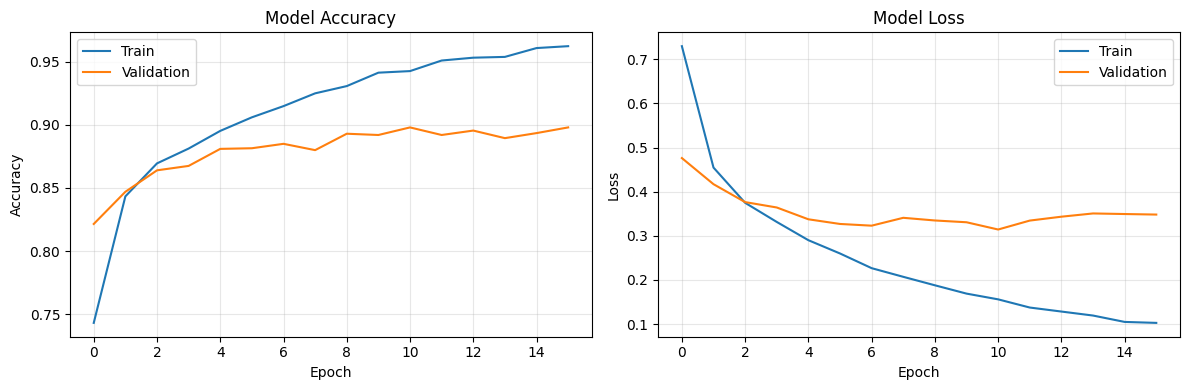

In [15]:
# Plot training history
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history.history['accuracy'], label='Train')
axes[0].plot(history.history['val_accuracy'], label='Validation')
axes[0].set_title('Model Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(history.history['loss'], label='Train')
axes[1].plot(history.history['val_loss'], label='Validation')
axes[1].set_title('Model Loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

---
## 7. Results Analysis

In [16]:
# Get trials summary
print("=" * 50)
print("TUNING RESULTS SUMMARY")
print("=" * 50)

print("\nTop 3 CNN Models:")
top_models = cnn_tuner.get_best_models(num_models=3)
for i, model in enumerate(top_models):
    loss, acc = model.evaluate(X_test, y_test, verbose=0)
    print(f"  Model {i+1}: Test Accuracy = {acc:.4f}")

TUNING RESULTS SUMMARY

Top 3 CNN Models:
  Model 1: Test Accuracy = 0.8829
  Model 2: Test Accuracy = 0.8788
  Model 3: Test Accuracy = 0.8832


In [17]:
# Visualize hyperparameter importance (based on trial results)
cnn_tuner.results_summary(num_trials=5)

Results summary
Results in tuner_results/cnn_tuning
Showing 5 best trials
Objective(name="val_accuracy", direction="max")

Trial 0017 summary
Hyperparameters:
num_conv_blocks: 1
filters_0: 32
kernel_size_0: 3
batch_norm_0: False
dense_units: 192
dropout: 0.4
learning_rate: 0.0008790667623039506
filters_1: 64
kernel_size_1: 5
batch_norm_1: False
filters_2: 128
kernel_size_2: 3
batch_norm_2: False
tuner/epochs: 15
tuner/initial_epoch: 5
tuner/bracket: 2
tuner/round: 2
tuner/trial_id: 0012
Score: 0.8945000171661377

Trial 0016 summary
Hyperparameters:
num_conv_blocks: 3
filters_0: 128
kernel_size_0: 3
batch_norm_0: False
dense_units: 256
dropout: 0.30000000000000004
learning_rate: 0.0010360153239971654
filters_1: 128
kernel_size_1: 5
batch_norm_1: False
filters_2: 128
kernel_size_2: 5
batch_norm_2: False
tuner/epochs: 15
tuner/initial_epoch: 5
tuner/bracket: 2
tuner/round: 2
tuner/trial_id: 0014
Score: 0.8899999856948853

Trial 0024 summary
Hyperparameters:
num_conv_blocks: 1
filters_0: 3

---
## Summary

### Keras Tuner Methods:

| Tuner | Strategy | Best For |
|-------|----------|----------|
| **RandomSearch** | Random sampling | Initial exploration |
| **Hyperband** | Adaptive allocation | Large search spaces |
| **BayesianOptimization** | Bayesian modeling | Efficient optimization |

### Hyperparameter Types:

| Method | Description | Example |
|--------|-------------|--------|
| `hp.Int()` | Integer range | num_layers, units |
| `hp.Float()` | Float range | learning_rate, dropout |
| `hp.Choice()` | Categorical | optimizer, kernel_size |
| `hp.Boolean()` | True/False | use_batch_norm |

### Best Practices:
1. Start with RandomSearch for exploration
2. Use Hyperband for large search spaces
3. Use BayesianOptimization for fine-tuning
4. Always use early stopping in trials
5. Train best model with more epochs after tuning